In [1]:
!pip install ptflops

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support, 
                             roc_auc_score, confusion_matrix, roc_curve, auc)
from sklearn.preprocessing import label_binarize
from ptflops import get_model_complexity_info

# PART 1: CONFIGURATION

In [2]:
MODEL_NAME = "MobileNetV2"
TEST_SIZE = 0.20  # Next split ratio
RATIO_LABEL = "80:20"
INPUT_SIZE = (224, 224) 
BATCH_SIZE = 64
EPOCHS = 50


In [4]:
# --- GPU SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | GPU: {torch.cuda.get_device_name(0)}")

Device: cuda | GPU: Tesla P100-PCIE-16GB


# PART 2: DATA LOADING & PREPARATION

In [6]:
CSV_FILE = "/kaggle/input/datasets/deadcardassian/pm25vision/train/metadata.csv"
IMG_DIR = "/kaggle/input/datasets/deadcardassian/pm25vision/train/images"

df_master = pd.read_csv(CSV_FILE)
df_master.iloc[:, 1] = (df_master.iloc[:, 1] - df_master.iloc[:, 1].min()).clip(0, 5)

class PM25Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img_name = os.path.basename(str(self.df.iloc[idx, 0]))
        if not img_name.lower().endswith('.jpg'): img_name += '.jpg'
        img_path = os.path.join(IMG_DIR, img_name)
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, int(self.df.iloc[idx, 1])

# Data Augmentation to prevent memorization
train_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# PART 3: ROBUST DATA SPLITTING

In [7]:
test_df = pd.DataFrame()
train_df = pd.DataFrame()

for class_id in range(6):
    class_subset = df_master[df_master.iloc[:, 1] == class_id]
    if len(class_subset) > 1:
        c_train, c_test = train_test_split(class_subset, test_size=TEST_SIZE, random_state=42)
        train_df = pd.concat([train_df, c_train])
        test_df = pd.concat([test_df, c_test])
    else:
        train_df = pd.concat([train_df, class_subset])

# Anti-Leakage Check
train_df = train_df[~train_df.iloc[:, 0].isin(test_df.iloc[:, 0])]

# PART 4: BALANCED SAMPLING

In [8]:
train_counts = train_df.iloc[:, 1].value_counts().to_dict()
class_weights_dict = {i: 1.0 / train_counts.get(i, 1e-6) for i in range(6)}
sample_weights = [class_weights_dict[label] for label in train_df.iloc[:, 1]]

sampler = torch.utils.data.WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

train_loader = DataLoader(PM25Dataset(train_df, train_transform), batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
test_loader = DataLoader(PM25Dataset(test_df, test_transform), batch_size=BATCH_SIZE, num_workers=2)

# PART 5: MODEL & TRAINING

In [9]:
model = models.mobilenet_v2(weights='IMAGENET1K_V1')
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5), # Prevent overfitting
    nn.Linear(model.last_channel, 6)
)
model = model.to(device)

macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)

loss_weight_tensor = torch.tensor([class_weights_dict[i] for i in range(6)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=loss_weight_tensor) 
optimizer = optim.Adam(model.parameters(), lr=5e-5) 

start_train_wall = time.time()
for epoch in range(EPOCHS):
    model.train()
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward()
        optimizer.step()
train_wall_time = time.time() - start_train_wall

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 145MB/s]


# PART 6: INFERENCE & VALIDATED EVALUATION


--- MobileNetV2 80:20 Final Validated Results ---
Accuracy: 0.2962 | Balanced Accuracy: 0.7651
F1-Score: 0.1741 | ROC-AUC: nan
Complexity: 319.03 MMac | Wall Time: Train 2603.25s


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


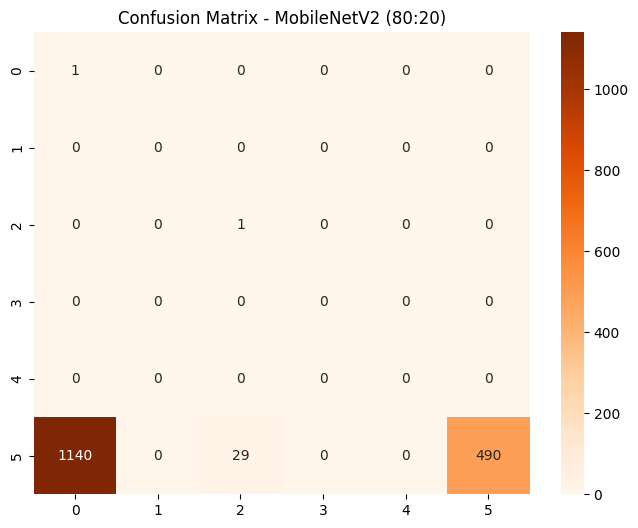

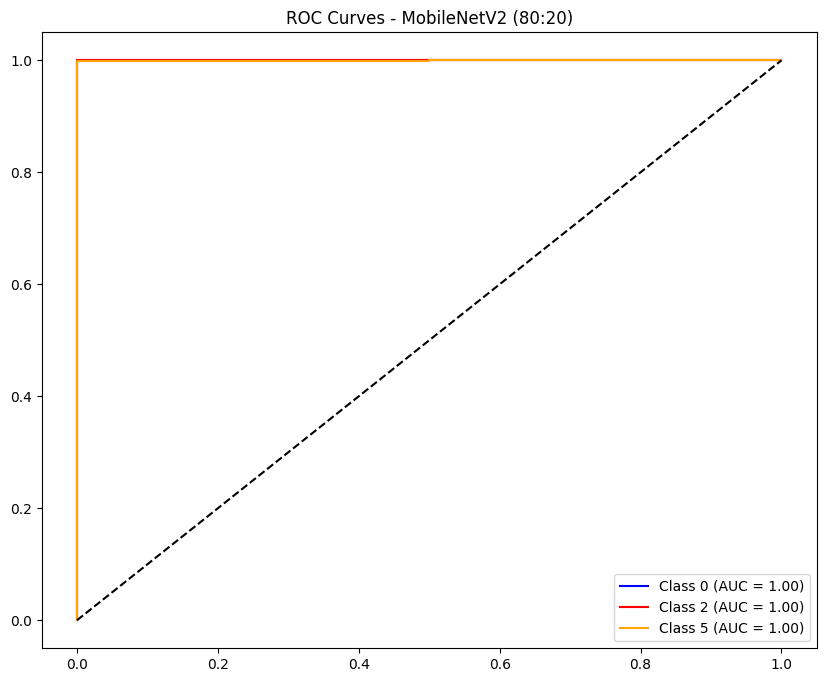

In [10]:
model.eval()
y_true, y_pred, y_probs = [], [], []
start_test_wall = time.time()

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        y_true.extend(lbls.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())
        y_probs.extend(probs.cpu().numpy())
test_wall_time = time.time() - start_test_wall

# Robust Metrics
all_classes = [0, 1, 2, 3, 4, 5]
acc = accuracy_score(y_true, y_pred)
bal_acc = balanced_accuracy_score(y_true, y_pred) # THE HONEST METRIC
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

y_true_np = np.array(y_true)
y_probs_np = np.array(y_probs)
actual_classes_in_test = np.unique(y_true_np)

if len(actual_classes_in_test) > 1:
    auc_score = roc_auc_score(label_binarize(y_true_np, classes=all_classes), y_probs_np, multi_class='ovr', average='macro')
else:
    auc_score = 0.0

print(f"\n--- {MODEL_NAME} {RATIO_LABEL} Final Validated Results ---")
print(f"Accuracy: {acc:.4f} | Balanced Accuracy: {bal_acc:.4f}")
print(f"F1-Score: {f1:.4f} | ROC-AUC: {auc_score:.4f}")
print(f"Complexity: {macs} | Wall Time: Train {train_wall_time:.2f}s")

# ==========================================
# PART 7: VISUALIZATION
# ==========================================
cm = confusion_matrix(y_true, y_pred, labels=all_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=all_classes, yticklabels=all_classes)
plt.title(f"Confusion Matrix - {MODEL_NAME} ({RATIO_LABEL})")
plt.show()

# Multi-class ROC Curve
y_true_bin = label_binarize(y_true, classes=all_classes)
plt.figure(figsize=(10,8))
colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'orange']
for i, color in zip(range(len(all_classes)), colors):
    if np.sum(y_true_bin[:, i]) > 0: 
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs_np[:, i])
        plt.plot(fpr, tpr, color=color, label=f'Class {i} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.title(f"ROC Curves - {MODEL_NAME} ({RATIO_LABEL})")
plt.legend(loc="lower right")
plt.show()

# SAVE CSV
res_df = pd.DataFrame([{
    "Model": MODEL_NAME, "Split": RATIO_LABEL, "Accuracy": acc, "Balanced_Acc": bal_acc, 
    "F1": f1, "AUC": auc_score, "TrainTime": train_wall_time, "GFLOPs": macs
}])
res_df.to_csv(f"results_{MODEL_NAME}_{RATIO_LABEL.replace(':','_')}.csv", index=False)